# Fine Tuning the Best Model

Notebook 03 picked one winning model. Here we tune its hyperparameters with `RandomizedSearchCV` and compare the tuned version against the original (untuned) base model on the same test set, so we can see whether fine tuning actually helped.

## Why RandomizedSearchCV (not GridSearchCV)?

Grid search visits every combination of every value, which scales poorly when you have five hyperparameters with three to four values each. Randomized search samples a fixed number of combinations from the same space. With only 8 samples and 3-fold CV (= 24 fits) we explore a wide range without an hour of training. If the gain from tuning is real, randomized search will find it; if there is no gain, neither method will help.

The dashboard only ever serves the tuned model from this notebook.

## Imports

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, learning_curve

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
PROC_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load splits and the base (untuned) winner

In [2]:
X_train = pd.read_csv(PROC_DIR / 'X_train_filtered.csv')
X_test = pd.read_csv(PROC_DIR / 'X_test_filtered.csv')
y_train = pd.read_csv(PROC_DIR / 'y_train.csv').squeeze('columns')
y_test = pd.read_csv(PROC_DIR / 'y_test.csv').squeeze('columns')

feature_meta = joblib.load(MODEL_DIR / 'feature_meta.joblib')
feature_cols = feature_meta['feature_cols']
num_cols = feature_meta['num_cols']
cat_cols = feature_meta['cat_cols']

best_name = joblib.load(MODEL_DIR / 'best_name.joblib')['best_name']
base_pipe = joblib.load(MODEL_DIR / f'{best_name}.joblib')
print('Best model from notebook 03:', best_name)

Best model from notebook 03: XGBoost


## Score the base model on the test set

In [3]:
base_pred = base_pipe.predict(X_test)
base_rmse = float(np.sqrt(mean_squared_error(y_test, base_pred)))
base_mae = float(mean_absolute_error(y_test, base_pred))
base_r2 = float(r2_score(y_test, base_pred))
print(f'Base {best_name}: RMSE={base_rmse:.4f}  MAE={base_mae:.4f}  R2={base_r2:.4f}')

Base XGBoost: RMSE=0.8712  MAE=0.6813  R2=0.8552


## Hyperparameter search

In [4]:
if best_name == 'RandomForest':
    grid = {
        'model__n_estimators': [200, 300],
        'model__max_depth': [15, 20],
        'model__min_samples_split': [2, 4],
        'model__min_samples_leaf': [1, 2],
        'model__max_features': ['sqrt', 0.7],
    }
elif best_name == 'GradientBoosting':
    grid = {
        'model__n_estimators': [150, 200],
        'model__learning_rate': [0.05, 0.08, 0.1],
        'model__max_depth': [4, 5, 6],
        'model__subsample': [0.85, 1.0],
    }
elif best_name == 'XGBoost':
    grid = {
        'model__n_estimators': [200, 300],
        'model__learning_rate': [0.05, 0.08, 0.1],
        'model__max_depth': [5, 6, 7],
        'model__subsample': [0.85, 1.0],
        'model__colsample_bytree': [0.85, 1.0],
    }
else:
    grid = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}

print('Search space:')
for k, v in grid.items():
    print(f'  {k}: {v}')

search = RandomizedSearchCV(
    base_pipe, grid, n_iter=8, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X_train, y_train)
tuned_pipe = search.best_estimator_
print()
print('Best params:', search.best_params_)

Search space:
  model__n_estimators: [200, 300]
  model__learning_rate: [0.05, 0.08, 0.1]
  model__max_depth: [5, 6, 7]
  model__subsample: [0.85, 1.0]
  model__colsample_bytree: [0.85, 1.0]



Best params: {'model__subsample': 0.85, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.85}


### What did the search actually try?

All 8 sampled hyperparameter combinations and their CV scores. This shows the search explored the space (not just stuck on one corner).

In [5]:
cv_results = pd.DataFrame(search.cv_results_)
cv_table = cv_results[['mean_test_score', 'std_test_score', 'params']].copy()
cv_table['CV_RMSE'] = (-cv_table['mean_test_score']).round(4)
cv_table['CV_RMSE_std'] = cv_table['std_test_score'].round(4)
cv_table = cv_table[['CV_RMSE', 'CV_RMSE_std', 'params']].sort_values('CV_RMSE').reset_index(drop=True)
cv_table

,CV_RMSE,CV_RMSE_std,params
0,0.8827,0.0046,"{'model__subsample': 0.85, 'model__n_estimator..."
1,0.8838,0.0045,"{'model__subsample': 0.85, 'model__n_estimator..."
2,0.8849,0.0057,"{'model__subsample': 0.85, 'model__n_estimator..."
3,0.8873,0.0062,"{'model__subsample': 0.85, 'model__n_estimator..."
4,0.8898,0.0036,"{'model__subsample': 0.85, 'model__n_estimator..."
5,0.8905,0.0024,"{'model__subsample': 0.85, 'model__n_estimator..."
6,0.8942,0.0071,"{'model__subsample': 0.85, 'model__n_estimator..."
7,0.8993,0.0036,"{'model__subsample': 0.85, 'model__n_estimator..."


## Score the tuned model on the same test set

In [6]:
tuned_pred = tuned_pipe.predict(X_test)
tuned_rmse = float(np.sqrt(mean_squared_error(y_test, tuned_pred)))
tuned_mae = float(mean_absolute_error(y_test, tuned_pred))
tuned_r2 = float(r2_score(y_test, tuned_pred))
print(f'Tuned {best_name}: RMSE={tuned_rmse:.4f}  MAE={tuned_mae:.4f}  R2={tuned_r2:.4f}')

Tuned XGBoost: RMSE=0.8632  MAE=0.6734  R2=0.8578


## Base vs tuned: did fine tuning help?

In [7]:
comparison = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2'],
    'Base': [round(base_rmse, 4), round(base_mae, 4), round(base_r2, 4)],
    'Tuned': [round(tuned_rmse, 4), round(tuned_mae, 4), round(tuned_r2, 4)],
})
comparison['Improvement'] = [
    round(base_rmse - tuned_rmse, 4),
    round(base_mae - tuned_mae, 4),
    round(tuned_r2 - base_r2, 4),
]
comparison['Improvement %'] = [
    round((base_rmse - tuned_rmse) / base_rmse * 100, 2),
    round((base_mae - tuned_mae) / base_mae * 100, 2),
    round((tuned_r2 - base_r2) / abs(base_r2) * 100, 2),
]
comparison

,Metric,Base,Tuned,Improvement,Improvement %
0,RMSE,0.8712,0.8632,0.0079,0.91
1,MAE,0.6813,0.6734,0.0079,1.16
2,R2,0.8552,0.8578,0.0026,0.31


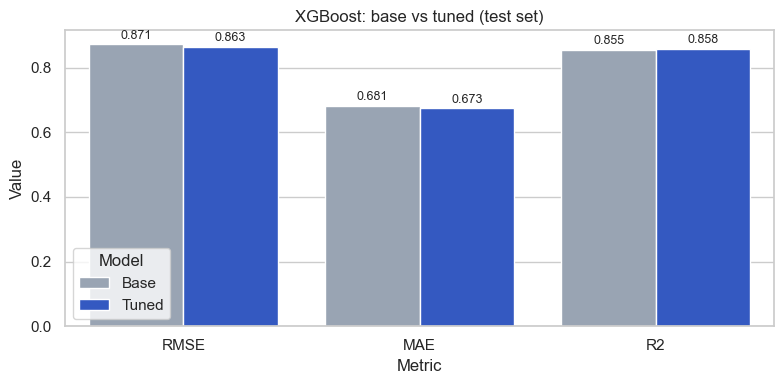

In [8]:
plot_df = comparison[['Metric', 'Base', 'Tuned']].melt(id_vars='Metric', var_name='Model', value_name='Value')
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=plot_df, x='Metric', y='Value', hue='Model',
            palette={'Base': '#94a3b8', 'Tuned': '#1d4ed8'}, ax=ax)
ax.set_title(f'{best_name}: base vs tuned (test set)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_base_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

## Save the tuned model and metadata

From here onward, only the tuned model is used. The dashboard loads `best_model.joblib` only.

In [9]:
joblib.dump(tuned_pipe, MODEL_DIR / f'{best_name}_tuned.joblib')
joblib.dump(tuned_pipe, MODEL_DIR / 'best_model.joblib')

metadata = {
    'best_model_name': best_name,
    'best_params': {k: (v if isinstance(v, (int, float, str, bool, type(None))) else str(v))
                    for k, v in search.best_params_.items()},
    'base_rmse': base_rmse,
    'base_mae': base_mae,
    'base_r2': base_r2,
    'tuned_rmse': tuned_rmse,
    'tuned_mae': tuned_mae,
    'tuned_r2': tuned_r2,
    'rmse_improvement_pct': round((base_rmse - tuned_rmse) / base_rmse * 100, 2),
    'r2_improvement_pct': round((tuned_r2 - base_r2) / abs(base_r2) * 100, 2),
    'feature_cols': feature_cols,
    'numeric_columns': num_cols,
    'categorical_columns': cat_cols,
    'train_size': int(X_train.shape[0]),
    'test_size': int(X_test.shape[0]),
    'random_state': RANDOM_STATE,
    'target': 'Yield',
}
with open(MODEL_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
metadata

{'best_model_name': 'XGBoost',
 'best_params': {'model__subsample': 0.85,
  'model__n_estimators': 300,
  'model__max_depth': 7,
  'model__learning_rate': 0.05,
  'model__colsample_bytree': 0.85},
 'base_rmse': 0.8711705994004457,
 'base_mae': 0.6813279039659534,
 'base_r2': 0.8551780852585175,
 'tuned_rmse': 0.8632281098722435,
 'tuned_mae': 0.6734312409986088,
 'tuned_r2': 0.857806739451574,
 'rmse_improvement_pct': 0.91,
 'r2_improvement_pct': 0.31,
 'feature_cols': ['Temperature',
  'Humidity',
  'Rainfall',
  'Soil_Type',
  'pH',
  'EC',
  'OC',
  'N',
  'P',
  'K',
  'Ca',
  'Mg',
  'S',
  'Zn',
  'Fe',
  'Cu',
  'Mn',
  'B',
  'Mo',
  'CEC',
  'Sand',
  'Silt',
  'Clay',
  'Bulk_Density',
  'Water_Holding_Capacity',
  'Slope',
  'Aspect',
  'Elevation',
  'Solar_Radiation',
  'Wind_Speed',
  'NDVI',
  'EVI',
  'LAI',
  'Chlorophyll',
  'GDD',
  'Crop_Type',
  'Growth_Stage',
  'Irrigation_Frequency',
  'Fertilizer_Type',
  'Pesticide_Usage',
  'Region',
  'Season',
  'Crop_Durat